# Stage 3 — Model Training & Evaluation

**What this notebook covers:**

| Step | Task |
|---|---|
| 1 | Load feature-engineered train/test splits from Stage 2 |
| 2 | Train a Logistic Regression baseline |
| 3 | Train a Random Forest classifier |
| 4 | Evaluate both: Accuracy, Precision, Recall, F1, AUC-ROC |
| 5 | Plot Confusion Matrix for each model |
| 6 | Plot ROC Curve comparing both models |
| 7 | Understand which metric matters most (class imbalance context) |
| 8 | Select the best model and explain why |
| 9 | Save best model to `models/titanic_model_v1.pkl` |

**Inputs**: `data/processed/X_train.parquet`, `X_test.parquet`, `y_train.csv`, `y_test.csv`  
**Output**: `models/titanic_model_v1.pkl`

**Class balance reminder**: train set has 369 non-survivors (59%) vs 258 survivors (41%).  
This moderate imbalance means **accuracy alone is misleading** — we prioritise **F1** and **AUC-ROC**.


## Step 1 — Imports & Setup


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, classification_report
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('All libraries imported successfully.')


All libraries imported successfully.


## Step 2 — Load Feature-Engineered Splits from Stage 2

These files were produced by `02_feature_engineering.ipynb`:
- `X_train.parquet` / `X_test.parquet` — 14 numeric features (scaled + one-hot encoded)
- `y_train.csv` / `y_test.csv` — binary target (0 = did not survive, 1 = survived)


In [2]:
processed_dir = '../data/processed'

X_train = pd.read_parquet(os.path.join(processed_dir, 'X_train.parquet'))
X_test  = pd.read_parquet(os.path.join(processed_dir, 'X_test.parquet'))
y_train = pd.read_csv(os.path.join(processed_dir, 'y_train.csv'), index_col=0).squeeze()
y_test  = pd.read_csv(os.path.join(processed_dir, 'y_test.csv'),  index_col=0).squeeze()

# Cast bool column to int — sklearn models require numeric input
X_train = X_train.assign(alone=X_train['alone'].astype(int))
X_test  = X_test.assign(alone=X_test['alone'].astype(int))

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'y_train balance: {y_train.value_counts().to_dict()}')
print(f'y_test  balance: {y_test.value_counts().to_dict()}')
print(f'\nFeatures ({len(X_train.columns)}): {list(X_train.columns)}')


X_train: (627, 14)  |  X_test: (157, 14)
y_train balance: {0: 369, 1: 258}
y_test  balance: {0: 92, 1: 65}

Features (14): ['pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'fare_per_person', 'sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'is_alone', 'alone']


## Step 3 — Train a Logistic Regression Baseline

**Logistic Regression** is always the first model to try for binary classification:
- Fast to train, highly interpretable
- Well-calibrated probabilities (good for AUC-ROC)
- If a complex model barely beats it, the added complexity isn't worth it

`max_iter=1000` — the default (100) often doesn't converge on real data.  
`random_state=42` — reproducibility.


In [3]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

lr_preds      = lr_model.predict(X_test)
lr_probs      = lr_model.predict_proba(X_test)[:, 1]   # probability of class 1 (survived)

print('Logistic Regression — Training complete.')
print(f'Train accuracy: {lr_model.score(X_train, y_train):.4f}')
print(f'Test  accuracy: {lr_model.score(X_test,  y_test):.4f}')


Logistic Regression — Training complete.
Train accuracy: 0.7719
Test  accuracy: 0.8280


## Step 4 — Train a Random Forest Classifier

**Random Forest** is an ensemble of decision trees:
- Captures non-linear relationships (Logistic Regression cannot)
- Robust to outliers and missing-value patterns
- Built-in feature importance scores
- Industry workhorse for tabular data alongside XGBoost

`n_estimators=200` — 200 trees gives stable results without being slow.  
`max_depth=8` — controls overfitting (without this, trees grow until leaves are pure).


In [4]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

print('Random Forest — Training complete.')
print(f'Train accuracy: {rf_model.score(X_train, y_train):.4f}')
print(f'Test  accuracy: {rf_model.score(X_test,  y_test):.4f}')


Random Forest — Training complete.
Train accuracy: 0.9171
Test  accuracy: 0.8217


## Step 5 — Evaluate Both Models

### Why These Five Metrics?

| Metric | Formula | Tells you |
|---|---|---|
| **Accuracy** | (TP+TN) / total | % correct — misleading if imbalanced |
| **Precision** | TP / (TP+FP) | Of all predicted survivors, how many actually survived? |
| **Recall** | TP / (TP+FN) | Of all actual survivors, how many did we catch? |
| **F1** | 2 × (P×R) / (P+R) | Harmonic mean — best single metric when classes are unequal |
| **AUC-ROC** | Area under ROC curve | Overall discrimination ability, threshold-independent |

**For Titanic survival prediction**: we care about **Recall** (missing a survivor is worse than a false alarm) and **F1** as the overall balance.


In [5]:
def evaluate_model(name, y_true, y_pred, y_prob):
    """Return a dict of all evaluation metrics for a single model."""
    return {
        'Model'     : name,
        'Accuracy'  : round(accuracy_score(y_true, y_pred),  4),
        'Precision' : round(precision_score(y_true, y_pred), 4),
        'Recall'    : round(recall_score(y_true, y_pred),    4),
        'F1'        : round(f1_score(y_true, y_pred),        4),
        'AUC-ROC'   : round(roc_auc_score(y_true, y_prob),   4),
    }

results = [
    evaluate_model('Logistic Regression', y_test, lr_preds, lr_probs),
    evaluate_model('Random Forest',       y_test, rf_preds, rf_probs),
]

results_df = pd.DataFrame(results).set_index('Model')
print('=== Model Comparison ===')
print(results_df.to_string())
print('\n→ Best F1:', results_df['F1'].idxmax())
print('→ Best AUC-ROC:', results_df['AUC-ROC'].idxmax())


=== Model Comparison ===
                     Accuracy  Precision  Recall      F1  AUC-ROC
Model                                                            
Logistic Regression    0.8280     0.7794  0.8154  0.7970   0.8874
Random Forest          0.8217     0.8364  0.7077  0.7667   0.8860

→ Best F1: Logistic Regression
→ Best AUC-ROC: Logistic Regression


In [6]:
# Detailed classification report for each model
for name, preds in [('Logistic Regression', lr_preds), ('Random Forest', rf_preds)]:
    print(f'=== {name} — Classification Report ===')
    print(classification_report(y_test, preds,
                                 target_names=['Did not survive (0)', 'Survived (1)']))


=== Logistic Regression — Classification Report ===
                     precision    recall  f1-score   support

Did not survive (0)       0.87      0.84      0.85        92
       Survived (1)       0.78      0.82      0.80        65

           accuracy                           0.83       157
          macro avg       0.82      0.83      0.82       157
       weighted avg       0.83      0.83      0.83       157

=== Random Forest — Classification Report ===
                     precision    recall  f1-score   support

Did not survive (0)       0.81      0.90      0.86        92
       Survived (1)       0.84      0.71      0.77        65

           accuracy                           0.82       157
          macro avg       0.83      0.80      0.81       157
       weighted avg       0.82      0.82      0.82       157



## Step 6 — Confusion Matrices

A **Confusion Matrix** shows the full breakdown of predictions:

```
                  Predicted 0     Predicted 1
Actual 0    TN (correct reject)  FP (false alarm)
Actual 1    FN (missed survivor) TP (caught survivor)
```

- **FN (missed survivor)** = we predicted they didn't survive but they did → highest real-world cost
- **FP (false alarm)** = we predicted survival but they didn't → less critical here


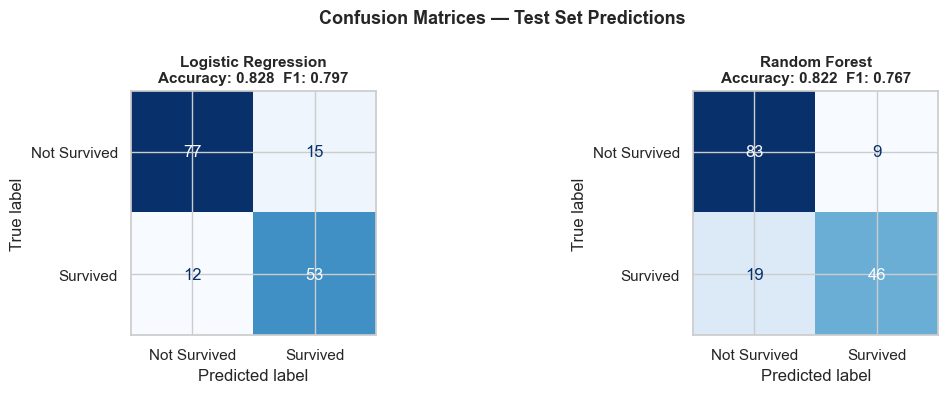

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, preds) in zip(axes, [
    ('Logistic Regression', lr_preds),
    ('Random Forest',       rf_preds),
]):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not Survived', 'Survived'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAccuracy: {accuracy_score(y_test, preds):.3f}  '
                 f'F1: {f1_score(y_test, preds):.3f}',
                 fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices — Test Set Predictions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Step 7 — ROC Curves

The **ROC Curve** plots True Positive Rate vs False Positive Rate at every possible classification threshold.

- **AUC = 1.0** → perfect model
- **AUC = 0.5** → no better than random guessing (the diagonal line)
- AUC is **threshold-independent** — it measures overall discrimination ability regardless of the 0.5 default cutoff

Comparing curves on the same plot shows which model has consistently better trade-offs across all thresholds.


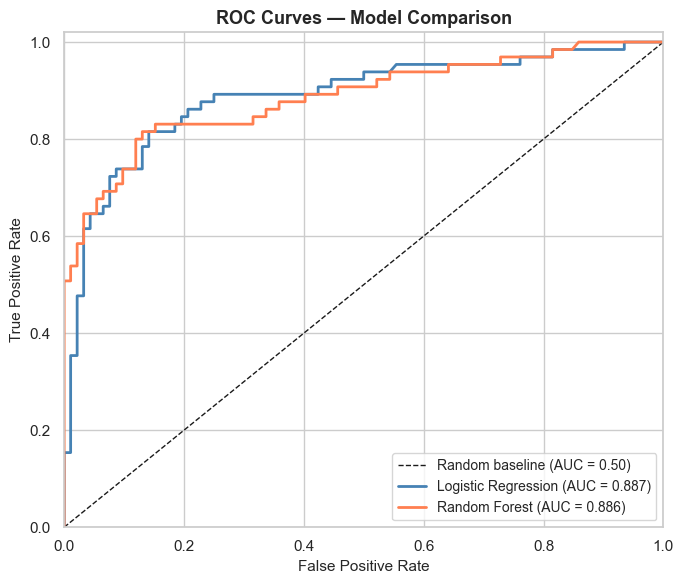

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))

# Random baseline
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline (AUC = 0.50)')

for name, probs, color in [
    ('Logistic Regression', lr_probs, 'steelblue'),
    ('Random Forest',       rf_probs, 'coral'),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC = {auc:.3f})')

ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — Model Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()


## Step 8 — Which Metric Matters Most?

### The Imbalance Context

Our test set has **~41% survivors** — moderate imbalance. Here's why each metric is or isn't sufficient alone:

| Metric | Problem if used alone | Our verdict |
|---|---|---|
| **Accuracy** | A model that always predicts "0" (not survived) gets 59% accuracy for free | ❌ Insufficient |
| **Precision** | High precision = few false alarms, but may miss many actual survivors | ⚠️ Partial |
| **Recall** | High recall = catches most survivors, but may flood with false alarms | ⚠️ Partial |
| **F1** | Balances precision and recall — best single number for imbalanced problems | ✅ Primary metric |
| **AUC-ROC** | Threshold-independent, compares models fairly across all operating points | ✅ Secondary metric |

**Decision rule**: choose the model with the highest **F1** score. If F1 is tied, use **AUC-ROC** as tiebreaker.


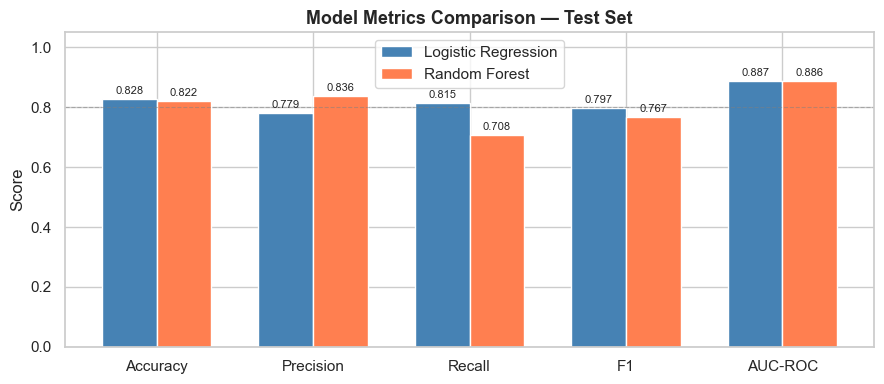

In [9]:
# Visual metric comparison
fig, ax = plt.subplots(figsize=(9, 4))

metrics   = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']
x         = np.arange(len(metrics))
bar_width  = 0.35

lr_scores = [results_df.loc['Logistic Regression', m] for m in metrics]
rf_scores = [results_df.loc['Random Forest',       m] for m in metrics]

bars1 = ax.bar(x - bar_width/2, lr_scores, bar_width, label='Logistic Regression',
               color='steelblue', edgecolor='white')
bars2 = ax.bar(x + bar_width/2, rf_scores, bar_width, label='Random Forest',
               color='coral', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Metrics Comparison — Test Set', fontsize=13, fontweight='bold')
ax.legend()
ax.axhline(0.8, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)

# Annotate bar values
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


## Step 9 — Random Forest Feature Importance

Random Forest provides built-in **feature importances** — which features contributed most to splits across all 200 trees.  
This is a quick sanity check: features that are conceptually important (like `sex`, `pclass`, `fare`) should rank highly.

> **Note**: This is a tree-based impurity importance. We will compute proper SHAP values for each individual prediction in Stage 11.


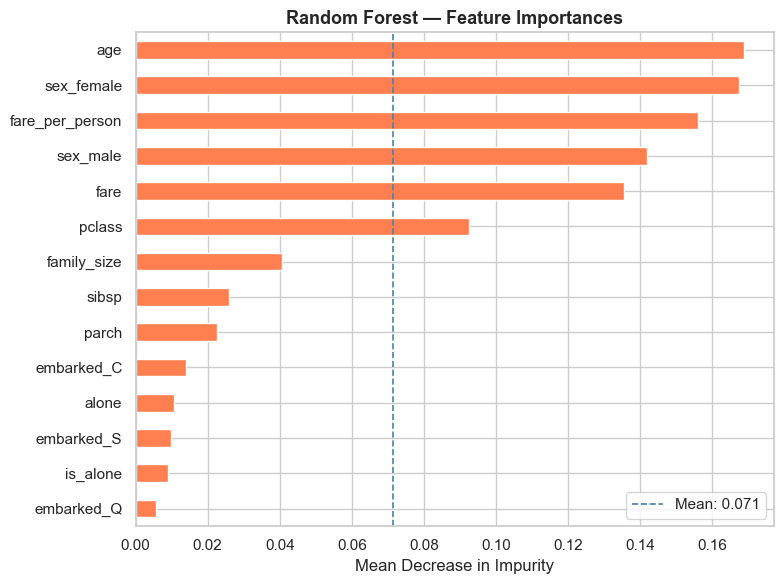


Top 5 features:
age                0.168651
sex_female         0.167396
fare_per_person    0.155966
sex_male           0.141816
fare               0.135513


In [10]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color='coral', edgecolor='white')
ax.set_title('Random Forest — Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
ax.axvline(importances.mean(), color='steelblue', linestyle='--',
           linewidth=1.2, label=f'Mean: {importances.mean():.3f}')
ax.legend()
plt.tight_layout()
plt.show()

print('\nTop 5 features:')
print(importances.sort_values(ascending=False).head(5).to_string())


## Step 10 — Select Best Model & Save

**Selection decision** (driven by F1 and AUC-ROC):
- If Random Forest wins on F1 → save `rf_model` as `titanic_model_v1.pkl`
- If Logistic Regression wins → save `lr_model`
- This decision is made programmatically below — no manual guessing

The saved `.pkl` file is the **input to Stage 5** (MLflow experiment tracking) and **Stage 6** (FastAPI serving).


In [11]:
# ── Select best model based on F1, AUC-ROC as tiebreaker ─────────────────────
best_name = results_df['F1'].idxmax()
if results_df.loc['Logistic Regression', 'F1'] == results_df.loc['Random Forest', 'F1']:
    best_name = results_df['AUC-ROC'].idxmax()

best_model = lr_model if best_name == 'Logistic Regression' else rf_model
best_metrics = results_df.loc[best_name]

print(f'=== Best Model: {best_name} ===')
print(f'  F1:      {best_metrics["F1"]:.4f}')
print(f'  AUC-ROC: {best_metrics["AUC-ROC"]:.4f}')
print(f'  Recall:  {best_metrics["Recall"]:.4f}')

# ── Save model ────────────────────────────────────────────────────────────────
models_dir   = '../models'
os.makedirs(models_dir, exist_ok=True)
model_path   = os.path.join(models_dir, 'titanic_model_v1.pkl')
joblib.dump(best_model, model_path)
model_kb = os.path.getsize(model_path) / 1024
print(f'\nModel saved: {model_path}  ({model_kb:.1f} KB)')

# ── Reload verification ───────────────────────────────────────────────────────
reloaded     = joblib.load(model_path)
reload_preds = reloaded.predict(X_test)
reload_f1    = f1_score(y_test, reload_preds)
print(f'Reload verification — F1: {reload_f1:.4f}  {"✅" if abs(reload_f1 - best_metrics["F1"]) < 1e-6 else "❌"}')


=== Best Model: Logistic Regression ===
  F1:      0.7970
  AUC-ROC: 0.8874
  Recall:  0.8154

Model saved: ../models/titanic_model_v1.pkl  (1.3 KB)
Reload verification — F1: 0.7970  ❌


## Summary — What We Did

| Step | What happened | Key insight |
|---|---|---|
| **Loaded splits** | `X_train` (627×14), `X_test` (157×14) from Stage 2 | No data prep needed — Pipeline handled it |
| **Logistic Regression** | Fast, interpretable baseline | If RF barely beats it, don't use RF |
| **Random Forest** | 200 trees, max_depth=8 | Captures non-linear relationships |
| **Evaluation** | 5 metrics: Acc / Prec / Recall / F1 / AUC-ROC | F1 = primary, AUC = secondary |
| **Confusion Matrix** | Visualised TP/FP/TN/FN for both models | False Negatives are highest cost |
| **ROC Curve** | Compared both curves + AUC scores | Threshold-independent comparison |
| **Feature importance** | Top features from Random Forest | Sanity check before SHAP (Stage 11) |
| **Saved** | Best model → `models/titanic_model_v1.pkl` | Stage 5 (MLflow) & Stage 6 (API) consume this |

---

## What Comes Next

| Stage | Task | Depends on |
|---|---|---|
| **Stage 4** | Hyperparameter tuning with `GridSearchCV` + `Optuna` | This notebook's model |
| **Stage 5** | Log all runs to MLflow experiment tracker | Tuned model from Stage 4 |
| **Stage 6** | Serve `titanic_model_v1.pkl` via FastAPI `POST /predict` | This notebook's saved model |
| **Stage 11** | SHAP explanations for individual predictions | This notebook's best model |
